# Test Set: Ensemble and 70% Confidence Interval

This is the test-set companion of `03_ky_modelling_xgboost_lightgbm`, which provides the two models fitted on train with the number of trees chosen on validation, and `04_ky_ensemble_and_intervals`, which provides the blend weight and the interval margins learned on **validation only**. The models are trained on `log1p(price)` and their predictions are converted back to dollars with `expm1` in `03_ky_modelling_xgboost_lightgbm`, so every number below is in dollars.

**This is the test-set notebook.** `04_ky_ensemble_and_intervals` fixed two things on the **validation** set only, the **blend weight** `w` and the **margin per N** of the 70% interval. This notebook takes those frozen numbers and applies them to the **test set**, whose properties were never used to fit or tune the models, the weight or the margins. It then reports the accuracy of the ensemble and the **success rate for each N basket and overall, together with the row counts.**

**Goal (agreed with the team):** At least **70% of households** should have their true value fall **inside their own predicted range**.

**Rules**
- **Evaluation only:** The test set is used for evaluation only and nothing is tuned on it. The weight and the margins come from the validation set and are frozen before any test row is used. Step 1 recomputes them from validation and checks that they equal the values saved by `04_ky_ensemble_and_intervals`.
- **Split:** The split is the classification model's property split, which gives 81 train, 18 validation and 13 test properties here.
- **Only notebook that scores the test set:** The test set was seen while the notebooks were being developed, so it is **not an untouched holdout for the whole project**. Here it is used for evaluation only and nothing is chosen from it.
- **Reference rows:** Train and validation rows are shown next to the test rows for reference, with the same frozen margins. Both are in-sample, because the models were fitted on the train rows and the margins were set on the validation rows, so only the test rows are a result.
- **No OOF and no cross-fitting:** The validation success rate is in-sample and is shown only as a diagnostic.
- **Small test set:** There are only 13 test households (5 at N = 30 and 3 at N = 50), so every number is very noisy.

In [1]:
import joblib
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd

PROCESSED = Path("../../data/processed/regression")     # modelling tables from 02_ky_data_preparation
INTERIM = Path("../../data/interim/regression")
MODELS = Path("../../models/regression")
REPORTS = Path("reports")
REPORTS.mkdir(parents=True, exist_ok=True)
print("models folder:", MODELS)

import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
plt.rcParams.update({"figure.figsize": (7, 3.6), "axes.spines.top": False, "axes.spines.right": False})

def wape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    return 100.0 * np.abs(y_true - y_pred).sum() / np.abs(y_true).sum()

preds = pd.read_parquet(INTERIM / "tuned_model_predictions.parquet")      # written by 03_ky_modelling_xgboost_lightgbm
val = preds[preds["split"] == "val"].reset_index(drop=True)
val_df = pd.read_parquet(PROCESSED / "val_df.parquet")
assert (val["Property_ID"].values == val_df["Property_ID"].values).all() and (val["n_documented"].values == val_df["n_documented"].values).all()
val["documented_value"] = val_df["sum_value"].values
frozen_file = pd.Series(joblib.load(MODELS / "ensemble_weight_and_margins.joblib"))    # written by 04_ky_ensemble_and_intervals
print(f"validation rows: {len(val)} / {val['Property_ID'].nunique()} properties | the test rows are first used in Step 2")

models folder: ..\..\models\regression


validation rows: 230 / 18 properties | the test rows are first used in Step 2


## 1. What is fixed from the validation set

Step 1 repeats the code of `04_ky_ensemble_and_intervals` on the **validation** predictions:
- **Blend weight:** `ensemble = w x XGBoost + (1 - w) x LightGBM`, with `w` from 0.00 to 1.00 in steps of 0.02, chosen to minimise the validation MAE.
- **Margin per N:** The relative error `|true - predicted| / predicted` is computed on the validation rows, and the margin is the **70th percentile of each N basket separately**. The interval is `prediction x (1 +/- margin)`.

These two quantities are computed here from the validation set, **checked against the values saved by `04_ky_ensemble_and_intervals`**, and then **frozen**.

In [2]:
CONF = 0.70
yv = val["true_total_value"]
grid = np.round(np.arange(0, 1.0001, 0.02), 2)
mae_by_w = [mean_absolute_error(yv, w * val["xgb_tuned_pred"] + (1 - w) * val["lgbm_tuned_pred"]) for w in grid]
best_w = float(grid[int(np.argmin(mae_by_w))])
val["ens"] = best_w * val["xgb_tuned_pred"] + (1 - best_w) * val["lgbm_tuned_pred"]
val["rel"] = (val["true_total_value"] - val["ens"]).abs() / val["ens"].clip(lower=1)
margin = val.groupby("n_documented")["rel"].quantile(CONF).rename("margin")

# check against the values saved by 04_ky_ensemble_and_intervals, then freeze them
saved_margin = pd.Series({int(k.split("=")[1]): v for k, v in frozen_file.items() if k.startswith("margin_N=")})
assert abs(best_w - frozen_file["blend_weight_xgboost"]) < 1e-9, (best_w, frozen_file["blend_weight_xgboost"])
assert np.allclose(margin.sort_index().values, saved_margin.sort_index().values), (margin, saved_margin)
print(f"blend weight (XGBoost share) = {best_w:.2f}   (LightGBM share = {1 - best_w:.2f})   validation MAE = ${min(mae_by_w):,.0f}   [equals the value saved by 04_ky_ensemble_and_intervals]")
print("margin per N (+/- %), from the validation rows [equal to the values saved by 04_ky_ensemble_and_intervals]:")
display((margin * 100).round(1).rename("margin (+/- %)").to_frame().T)

blend weight (XGBoost share) = 0.28   (LightGBM share = 0.72)   validation MAE = $36,514   [equals the value saved by 04_ky_ensemble_and_intervals]
margin per N (+/- %), from the validation rows [equal to the values saved by 04_ky_ensemble_and_intervals]:


n_documented,10,20,30,50
margin (+/- %),82.8,51.1,42.6,59.0


## 2. Accuracy of the ensemble on the test set

The two final models of `03_ky_modelling_xgboost_lightgbm` (`xgb_log_model.joblib` and `lgbm_log_model.joblib`) predict the test rows here, and the predictions are blended with the frozen weight. The train and validation MAE are shown next to the test MAE, and the train rows are in-sample because the models were fitted on them. The test MAE can be smaller or larger than the validation MAE. The 13 test households contain no very large home (the largest is $138,593, against $360,420 in validation), so this comparison says more about the homes than about the models.

In [3]:
import joblib
mx, ml = joblib.load(MODELS / "xgb_log_model.joblib"), joblib.load(MODELS / "lgbm_log_model.joblib")
test_df = pd.read_parquet(PROCESSED / "test_df.parquet")          # first use of the test rows
FEATURE_COLS = [c for c in test_df.columns if c not in ("Property_ID", "true_total_value")]
test = test_df[["Property_ID", "n_documented", "true_total_value"]].copy()
test["xgb_tuned_pred"] = np.expm1(mx.predict(test_df[FEATURE_COLS]))          # log-target models -> dollars
test["lgbm_tuned_pred"] = np.expm1(ml.predict(test_df[FEATURE_COLS]))
test["documented_value"] = test_df["sum_value"].values
test["ens"] = best_w * test["xgb_tuned_pred"] + (1 - best_w) * test["lgbm_tuned_pred"]
yt = test["true_total_value"]

# train rows (in-sample: these are the rows the two models were fitted on), predicted by the same two models
train_df = pd.read_parquet(PROCESSED / "train_df.parquet")
train = train_df[["Property_ID", "n_documented", "true_total_value"]].copy()
train["xgb_tuned_pred"] = np.expm1(mx.predict(train_df[FEATURE_COLS]))
train["lgbm_tuned_pred"] = np.expm1(ml.predict(train_df[FEATURE_COLS]))
train["ens"] = best_w * train["xgb_tuned_pred"] + (1 - best_w) * train["lgbm_tuned_pred"]
ytr = train["true_total_value"]
names = {"XGBoost": "xgb_tuned_pred", "LightGBM": "lgbm_tuned_pred", f"Ensemble (w = {best_w:.2f})": "ens"}
summary = pd.DataFrame({"train MAE ($, in-sample)": {k: mean_absolute_error(ytr, train[c]) for k, c in names.items()},
                        "validation MAE ($)": {k: mean_absolute_error(yv, val[c]) for k, c in names.items()},
                        "test MAE ($)": {k: mean_absolute_error(yt, test[c]) for k, c in names.items()},
                        "train WAPE (%)": {k: wape(ytr, train[c]) for k, c in names.items()},
                        "validation WAPE (%)": {k: wape(yv, val[c]) for k, c in names.items()},
                        "test WAPE (%)": {k: wape(yt, test[c]) for k, c in names.items()}})
display(summary.style.format({"train MAE ($, in-sample)": "{:,.0f}", "validation MAE ($)": "{:,.0f}", "test MAE ($)": "{:,.0f}",
                              "train WAPE (%)": "{:.1f}", "validation WAPE (%)": "{:.1f}", "test WAPE (%)": "{:.1f}"}))

def mae_by_n(df): return df.groupby("n_documented").apply(lambda g: mean_absolute_error(g.true_total_value, g.ens))
by_n = pd.DataFrame({"test households": test.groupby("n_documented")["Property_ID"].nunique(), "test rows": test.groupby("n_documented").size(),
                     "ensemble train MAE ($, in-sample)": mae_by_n(train), "ensemble validation MAE ($)": mae_by_n(val), "ensemble test MAE ($)": mae_by_n(test),
                     "ensemble test WAPE (%)": test.groupby("n_documented").apply(lambda g: wape(g.true_total_value, g.ens))}).round(1)
by_n.index.name = "N documented"
display(by_n)

,"train MAE ($, in-sample)",validation MAE ($),test MAE ($),train WAPE (%),validation WAPE (%),test WAPE (%)
XGBoost,"35,515","37,535","22,014",34.7,49.9,39.8
LightGBM,"33,914","36,793","18,663",33.1,48.9,33.8
Ensemble (w = 0.28),"34,200","36,514","19,544",33.4,48.5,35.4


,test households,test rows,"ensemble train MAE ($, in-sample)",ensemble validation MAE ($),ensemble test MAE ($),ensemble test WAPE (%)
N documented,,,,,,
10,13,65,33962.7,37444.7,22716.1,47.5
20,9,45,37824.4,36636.7,18901.9,34.6
30,5,25,37546.2,36182.3,17506.3,26.1
50,3,15,21585.2,33953.7,11118.2,15.9


## 3. The 70% interval on the test set: success rate per N and overall

For every test row, `lower = prediction x (1 - margin_N)` and `upper = prediction x (1 + margin_N)`, using the **frozen validation margin of that row's own N basket**. A row is a success when the true total value is inside `[lower, upper]`.

- `households` and `total_rows`: These show how many test properties and rows each N basket has.
- `success_rate_pct` and `hh_success_rate_pct`: The first is the **row-level** success rate (hit rows divided by all rows), and the second is the **household-level** success rate (the average of each household's own hit rate). Both are defined with an example in the next sub-section.
- `above band` and `below band`: The first counts rows where the true value is **above** the upper bound (the model under-predicted), and the second counts rows where it is below the lower bound.
- `+/- SE (pts)`: This is the standard error of the household-level success rate over households. The rows of one household are correlated, so the real sample size is the number of households and not the number of rows.
- **Floor at the documented value:** The true total can never be below the value already documented in the basket, so `lower_floor = max(lower, documented value)`. This never removes a hit and only narrows the interval, and the median widths are shown for both versions.

### Row-level vs household-level success rate (definitions and example)

The tables show a **success rate**, which can be counted in two ways that give slightly different numbers.

**Definitions**
- **Row:** One simulated draw, meaning one property with N documented items and one random draw. Each row has its own `n_documented` (N), its own prediction and its own interval. A property has up to 4 values of N with 5 draws each, which gives **20 rows**, and a property with 10 to 19 items has only 5 rows (N = 10 only).
- **Household:** One `Property_ID`. In this project a household is one property.
- **Hit:** A row is a hit when its true total value is inside its own interval `[lower, upper]`.
- **Row-level success rate:** The number of hit rows divided by the number of all rows. All rows are pooled, so a household with many rows counts more.
- **Household-level success rate:** First work out **each household's own hit rate** (its hit rows divided by its own rows), then take the **average of those rates over households**. Every household counts the same, however many rows it has.

**Example (illustrative numbers)**

| Household | Rows | Hit rows | Its own hit rate |
|---|---|---|---|
| A (large home) | 20 (5 for each of N = 10, 20, 30, 50) | 12 | 12 / 20 = **60%** |
| B (small home) | 5 (N = 10 only) | 5 | 5 / 5 = **100%** |

The row-level rate is (12 + 5) / (20 + 5) = **68%**, and the household-level rate is (60% + 100%) / 2 = **80%**. The two differ because the large home contributes four times as many rows. The team goal is stated for households, so the household-level rate is the one to compare with 70%.

In [4]:
test["margin"] = test["n_documented"].map(margin)
test["lower"], test["upper"] = test["ens"] * (1 - test["margin"]), test["ens"] * (1 + test["margin"])
test["lower_floor"] = np.maximum(test["lower"], test["documented_value"])
test["inside"] = (yt >= test["lower"]) & (yt <= test["upper"])
test["inside_floor"] = (yt >= test["lower_floor"]) & (yt <= test["upper"])
test["above"], test["below"] = yt > test["upper"], yt < test["lower"]
test["rel"] = (yt - test["ens"]).abs() / test["ens"].clip(lower=1)
test["width"], test["width_floor"] = test["upper"] - test["lower"], test["upper"] - test["lower_floor"]

def hh_se(g):                                   # standard error over households (rows of a household are correlated)
    h = g.groupby("Property_ID")["inside"].mean()
    return 100 * h.std() / np.sqrt(len(h)) if len(h) > 1 else np.nan

def block(g):
    return pd.Series({"households": g["Property_ID"].nunique(), "total_rows": len(g), "successful_rows": int(g["inside"].sum()),
                      "missed_rows": int((~g["inside"]).sum()), "success_rate_pct": 100 * g["inside"].mean(),
                      "hh_success_rate_pct": 100 * g.groupby("Property_ID")["inside"].mean().mean(), "se_pts": hh_se(g),
                      "above_band": int(g["above"].sum()), "below_band": int(g["below"].sum()),
                      "median_width": g["width"].median(), "median_width_floor": g["width_floor"].median(),
                      "hits_lost_by_floor": int((g["inside"] & ~g["inside_floor"]).sum())})

tab = test.groupby("n_documented").apply(block)
tab.insert(0, "margin_pct", margin * 100)
tab.index = tab.index.astype(str)
tab.loc["ALL"] = block(test)
display(tab.round(1))

rate, se = tab.loc["ALL", "hh_success_rate_pct"], tab.loc["ALL", "se_pts"]
verdict = ("within 2 standard errors of 70%: the test set cannot tell it apart from the target" if abs(rate - 70) <= 2 * se else
           ("more than 2 standard errors ABOVE 70% (the intervals are wider than needed on these test homes)" if rate > 70 else
            "more than 2 standard errors BELOW 70% (the intervals are too narrow on these test homes)"))
print(f"household-level success {rate:.1f}% (SE {se:.1f} pts) vs target 70%: {verdict}")
print(f"row-level success {tab.loc['ALL', 'success_rate_pct']:.1f}% ({int(tab.loc['ALL', 'successful_rows'])} of {int(tab.loc['ALL', 'total_rows'])} rows)")
whole_t = np.isclose(test["documented_value"], test["true_total_value"])
print(f"rows where the basket is the whole home: {int(whole_t.sum())} of {len(test)}. Success rate without them: {100 * test.loc[~whole_t, 'inside'].mean():.1f}%")

,margin_pct,households,total_rows,successful_rows,missed_rows,success_rate_pct,hh_success_rate_pct,se_pts,above_band,below_band,median_width,median_width_floor,hits_lost_by_floor
n_documented,,,,,,,,,,,,,
10,82.8,13.0,65.0,55.0,10.0,84.6,84.6,9.4,10.0,0.0,64246.1,55660.2,0.0
20,51.1,9.0,45.0,35.0,10.0,77.8,77.8,12.2,3.0,7.0,55858.9,48332.6,0.0
30,42.6,5.0,25.0,24.0,1.0,96.0,96.0,4.0,1.0,0.0,66712.5,60250.5,0.0
50,59.0,3.0,15.0,15.0,0.0,100.0,100.0,0.0,0.0,0.0,54069.3,42978.3,0.0
ALL,NaN,13.0,150.0,129.0,21.0,86.0,87.6,5.1,14.0,7.0,61565.6,53246.7,0.0


household-level success 87.6% (SE 5.1 pts) vs target 70%: more than 2 standard errors ABOVE 70% (the intervals are wider than needed on these test homes)
row-level success 86.0% (129 of 150 rows)
rows where the basket is the whole home: 5 of 150. Success rate without them: 85.5%


In [5]:
# Row-level vs household-level, on the real data of this notebook (hit flag: `inside` in `test`)
per_hh = test.groupby("Property_ID")["inside"].agg(rows="size", hits="sum")
per_hh["own hit rate (%)"] = (100 * per_hh["hits"] / per_hh["rows"]).round(1)
target = per_hh["own hit rate (%)"].mean()          # among households with the same row count, pick one with a typical hit rate
pick = lambda n: (per_hh[per_hh["rows"] == n]["own hit rate (%)"] - target).abs().idxmin()
big, small = pick(per_hh["rows"].max()), pick(per_hh["rows"].min())
ex = per_hh.loc[[big, small]]
print("two real households from this notebook: the one with the most rows and the one with the fewest rows")
display(ex)
row_lvl = 100 * ex["hits"].sum() / ex["rows"].sum()
hh_lvl = ex["own hit rate (%)"].mean()
print(f"for these two households: row-level = ({int(ex['hits'].iloc[0])} + {int(ex['hits'].iloc[1])}) / ({int(ex['rows'].iloc[0])} + {int(ex['rows'].iloc[1])}) = {row_lvl:.1f}%   |   household-level = average of {ex['own hit rate (%)'].iloc[0]}% and {ex['own hit rate (%)'].iloc[1]}% = {hh_lvl:.1f}%")

two real households from this notebook: the one with the most rows and the one with the fewest rows


,rows,hits,own hit rate (%)
Property_ID,,,
PRP-000104,20,20,100.0
PRP-000529,5,4,80.0


for these two households: row-level = (20 + 4) / (20 + 5) = 96.0%   |   household-level = average of 100.0% and 80.0% = 90.0%


In [6]:
tab.assign(blend_w_xgb=best_w).to_csv(REPORTS / "test_interval_results.csv")
test[["Property_ID", "n_documented", "true_total_value", "documented_value", "xgb_tuned_pred", "lgbm_tuned_pred", "ens", "margin", "lower", "lower_floor", "upper", "inside", "inside_floor"]].to_parquet(INTERIM / "test_ensemble_predictions.parquet", index=False)
print("saved test_interval_results.csv to", REPORTS, "and test_ensemble_predictions.parquet to", INTERIM)

saved test_interval_results.csv to reports and test_ensemble_predictions.parquet to ..\..\data\interim\regression


## 4. Train, validation (both in-sample) and test, side by side

The same frozen margins are applied to the **train rows**, the **validation rows** and the **test rows**, and the success rate is counted per N at row level. There is no cross-fitted rate, because no OOF predictions are used, and the first two columns are in-sample in different ways, so **only the test column is a result**:
- **Train rows:** They were used to fit the two models, so their predictions are better than they would be on new homes, while the margins come from the validation rows.
- **Validation rows:** They set the margins, so their rate sits near 70% by construction.

The columns `70th-pct relative error` and `pred / true` are **diagnostics only** and must **not** be used to set new margins, because that would tune on the test set.
- `70th-pct relative error`: This is the margin that would have given exactly 70% on the rows of that set and N, and it can be compared with the frozen margin.
- `pred / true`: This is the sum of the predictions divided by the sum of the true values, and a value below 1 means that the models under-predict on average.

frozen margin (%) success rate (%)                     \
                                          train validation    test   
N documented                                                         
10                       82.78            91.11      73.33   84.62   
20                       51.11            86.67      67.69   77.78   
30                       42.58            88.57      68.89   96.00   
50                       59.03            91.54      70.00  100.00   
ALL                        NaN            89.42      70.43   86.00   

             70th-pct relative error (%)                   pred / true  \
                                   train validation   test       train   
N documented                                                             
10                                 42.01      82.78  69.60        0.69   
20                                 18.93      51.11  49.30        0.68   
30                                 15.94      42.58  26.26        0.74   
50                                  6.33      59.03  23.80        0.83   
ALL                                23.87      68.67  43.56        0.72   

                               
             validation  test  
N documented                   
10                 0.65  0.97  
20                 0.80  1.03  
30                 0.80  1.01  
50                 0.82  0.99  
ALL                0.76  1.00

rows: train 1030 | validation 230 | test 150


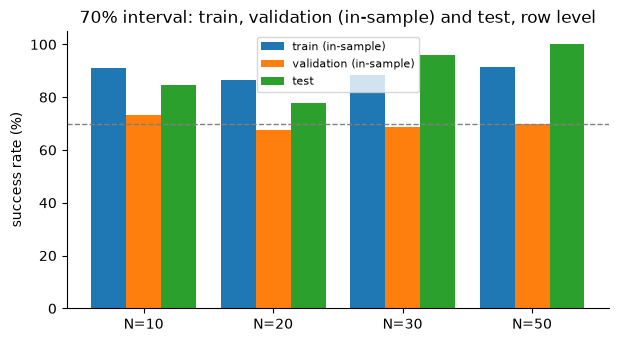

In [7]:
for df in (train, val, test):
    df["margin"] = df["n_documented"].map(margin)
    df["rel"] = (df["true_total_value"] - df["ens"]).abs() / df["ens"].clip(lower=1)
    df["inside"] = (df["true_total_value"] >= df["ens"] * (1 - df["margin"])) & (df["true_total_value"] <= df["ens"] * (1 + df["margin"]))
sets = {"train": train, "validation": val, "test": test}
def per_n(f): return pd.DataFrame({k: f(d) for k, d in sets.items()})
ratio = lambda d: d.groupby("n_documented").apply(lambda g: g["ens"].sum() / g["true_total_value"].sum())
succ = per_n(lambda d: d.groupby("n_documented")["inside"].mean() * 100)
relq = per_n(lambda d: d.groupby("n_documented")["rel"].quantile(CONF) * 100)
rat = per_n(ratio)
cmp_ = pd.concat({"success rate (%)": succ, "70th-pct relative error (%)": relq, "pred / true": rat}, axis=1)
cmp_.insert(0, ("frozen margin (%)", ""), margin * 100)
cmp_.loc["ALL"] = [np.nan] + [100 * d["inside"].mean() for d in sets.values()] + [100 * d["rel"].quantile(CONF) for d in sets.values()] + [d["ens"].sum() / d["true_total_value"].sum() for d in sets.values()]
cmp_.index.name = "N documented"
display(cmp_.round(2))
print("rows: train", len(train), "| validation", len(val), "| test", len(test))

fig, ax = plt.subplots()
x = np.arange(len(succ.index))
w_ = 0.27
ax.bar(x - w_, succ["train"], w_, label="train (in-sample)")
ax.bar(x, succ["validation"], w_, label="validation (in-sample)")
ax.bar(x + w_, succ["test"], w_, label="test")
ax.axhline(70, color="grey", ls="--", lw=1)
ax.set_xticks(x)
ax.set_xticklabels([f"N={i}" for i in succ.index])
ax.set_ylabel("success rate (%)")
ax.set_title("70% interval: train, validation (in-sample) and test, row level")
ax.legend(fontsize=8)
plt.show()
cmp_.to_csv(REPORTS / "interval_results_train_validation_test.csv")

## 5. What to read from this

- **Train and validation columns:** Both are in-sample, because the models were fitted on the train rows and the margins were set on the validation rows. They show how the interval behaves on rows the models know, and only the test column is a result.
- **Row-level versus household-level:** Both rates are printed in Section 3 and defined, with an example, in the sub-section *Row-level vs household-level success rate*. The team goal is stated for households.
- **Stage 1 on the test set:** Compare the **ALL** household-level success rate in Section 3 with 70%. The printed verdict uses the standard error over households, and if the rate is within 2 standard errors of 70% the test set cannot tell it apart from the target.
- **N baskets with few households:** There are 13 test households here, with 5 at N = 30 and 3 at N = 50. These baskets have wide error bars, so a gap of several points in one basket is noise and not a finding.
- **Direction of the misses:** If `above band` is larger than `below band`, the model predicts too low for large homes, so the true value falls above the upper bound.
- **Margins come from validation, not from OOF:** With 18 validation properties each margin is uncertain (`04_ky_ensemble_and_intervals` shows a bootstrap range), and the validation homes are harder than the test homes, which is the likely reason the test rate is above 70%.
- **Known limitation:** Validation chose the hyperparameters and the number of trees (`03_ky_modelling_xgboost_lightgbm`) and the weight and margins (`04_ky_ensemble_and_intervals`), and the test set was seen while the notebooks were developed, so this is not an untouched holdout.
- **Not done here:** Tuning the bounds, which would be a possible Stage 2. If it is done later it must be tuned on validation, and the test set must stay untouched.

## Test results and how to read them (numbers from the run above)

- **Frozen from validation and checked:** The weight is 0.28 (XGBoost share), and the margins are 82.8% for N = 10, 51.1% for N = 20, 42.6% for N = 30 and 59.0% for N = 50. They were recomputed here from the validation rows and equal the values saved by `04_ky_ensemble_and_intervals`. Nothing was tuned on the test set.
- **Accuracy on the 13 test households (150 rows):** The two saved final models of `03_ky_modelling_xgboost_lightgbm` give an ensemble MAE of **$19,544** (WAPE 35.4%), against $22,014 (39.8%) for XGBoost and $18,663 (33.8%) for LightGBM. The validation MAE of the same three is $36,514, $37,535 and $36,793. The test error is about half of the validation error because the test homes contain no very large home (the largest is $138,593, against $360,420 in validation). The blend is better than XGBoost and about $880 worse than LightGBM alone. By N, the ensemble test MAE and WAPE are $22,716 and 47.5% (N = 10), $18,902 and 34.6% (N = 20), $17,506 and 26.1% (N = 30), and $11,118 and 15.9% (N = 50).
- **70% interval on the test set:** The household-level success rate is **87.6%** (standard error 5.1 points), and the row-level rate is **86.0%** (129 of 150 rows). By N at household level, the rate is 84.6% for N = 10 (13 households), 77.8% for N = 20 (9), 96.0% for N = 30 (5) and 100% for N = 50 (3). There are 14 misses above the band and 7 below it. Without the 5 whole-home rows the row-level rate is 85.5%.
- **Train, validation and test accuracy side by side (MAE and WAPE):** The ensemble gives $34,200 and 33.4% on the train rows (in-sample), $36,514 and 48.5% on validation, and $19,544 and 35.4% on test. XGBoost gives $35,515 and 34.7%, then $37,535 and 49.9%, then $22,014 and 39.8%. LightGBM gives $33,914 and 33.1%, then $36,793 and 48.9%, then $18,663 and 33.8%. The validation homes are the hardest because they include a $360,420 home. The test homes are close to the train homes in relative error (WAPE 35.4% against 33.4%) and have a much lower MAE because they are smaller. Only the test column is a result.
- **Train, validation and test side by side (70% interval, row level, same frozen margins):** The success rate on train is 91.1%, 86.7%, 88.6% and 91.5% by N (all 1,030 rows: 89.4%, in-sample). On validation it is 73.3%, 67.7%, 68.9% and 70.0% (all rows: 70.4%, in-sample and near 70% by construction). On test it is 84.6%, 77.8%, 96.0% and 100% (all rows: 86.0%). Train and test are both well above 70% because the margins come from the harder validation rows. The margin that would give exactly 70% is 42%, 19%, 16% and 6% on the train rows (all rows: 23.9%), 82.8%, 51.1%, 42.6% and 59.0% on validation (all rows: 68.7%), and 69.6%, 49.3%, 26.3% and 23.8% on test (all rows: 43.6%), against the frozen margins of 82.8%, 51.1%, 42.6% and 59.0%. The ratio `pred / true` is 0.72 on train, 0.76 on validation and 1.00 on test, which means that the models under-predict the train and validation homes, most of all the large ones, but not the test homes.
- **Verdict:** The household rate is more than 2 standard errors **above** the 70% target, so the intervals are **wider than needed on these test homes**. The target is "at least 70%", so it is met, but not tightly. The test set has only 13 households, so this does not show that the method gives 70% on other homes.
- **Why the test rate is above 70% (diagnostics, not used to change anything):** The validation set under-predicts (the sum of predictions divided by the sum of true values is 0.76, and 0.65 at N = 10), which produces large relative errors and wide margins. On the test set the ensemble is unbiased (ratio 1.00). The margin that would give exactly 70% on the test rows is 69.6% for N = 10 (frozen 82.8%), 49.3% for N = 20 (frozen 51.1%), 26.3% for N = 30 (frozen 42.6%) and 23.8% for N = 50 (frozen 59.0%). The frozen margins are therefore close for N = 10 and 20 and far too wide for N = 30 and 50, which have 5 and 3 households.
- **The intervals are wide:** The median width on the test set is about $61,600 ($53,200 with the floor at the documented value), against a test MAE of $19,544. The floor never removed a hit (0 hits lost).
- **Row-level versus household-level, real example:** PRP-000104 (20 rows, 20 hits, 100%) and PRP-000529 (5 rows, 4 hits, 80%) give a row-level rate of 96.0% and a household-level rate of 90.0%.
- **Limits:** There are only 13 test households (5 at N = 30 and 3 at N = 50), and the margins come from 18 validation properties. Validation was used for the hyperparameters, the number of trees, the weight and the margins. This notebook is the only one that scores the test set, but the test set was seen while the notebooks were being developed, so it is not an untouched holdout for the whole project.
- **Files:** `notebooks/regression/reports/` holds `test_interval_results.csv` and `interval_results_train_validation_test.csv`. `data/interim/regression/` holds `test_ensemble_predictions.parquet`.